# Tutorial: Forecasting ENSO using Machine Learning

By the end of this tutorial, you will understand the full pipeline for building ML-based ENSO prediction systems from data loading to evaluation.

# Introduction

The **El Niño–Southern Oscillation (ENSO)** is a major driver of climate variability on seasonal and interannual time-scales, influencing regional and global weather patterns [1-3]. It has been linked to extreme weather events across the globe, including droughts, floods, and shifts in precipitation [4-6]. Weather centres around the world actively forecast ENSO to anticipate these patterns as part of their seasonal prediction systems [7].

# Background
ENSO is a coupled ocean-atmosphere phenomenon characterised by irregular fluctuations in winds and sea surface temperatures (SST) over the tropical Pacific Ocean on time-scales of months to years. ENSO has two primary phases: **El Niño** (warming) and **La Niña** (cooling), along with neutral conditions.  
However, ENSO itself is not a single, directly observed variable; rather, it is a large-scale climate pattern with impacts spanning many regions.

To quantify and monitor ENSO, climate scientists use numerical indices that summarise specific aspects of this system. One commonly used metric is the **Niño3.4 index**, which measures the average SST anomaly within a defined region of the equatorial Pacific (5°N-5°S, 170°W-120°W). This index acts as a proxy for ENSO state:

- **Positive Niño3.4 values** typically correspond to El Niño events.
- **Negative values** indicate La Niña events.

The Niño3.4 index provides a simple, quantitative way to track and forecast ENSO phases. 

The figure below (sourced from [8]) illustrates the atmospheric and oceanic structure during La Niña (left) and El Niño (right). The **black box** drawn over the Pacific indicates the Niño4 region, as opposed to Niño3.4 used here. The indices are defined in the same way, but differ by the position of the box in the Pacific, with Niño4 capturing central Pacific variability and Niño3.4 capturing eastern Pacific variability.
<figure style="text-align:center; margin:0;">
  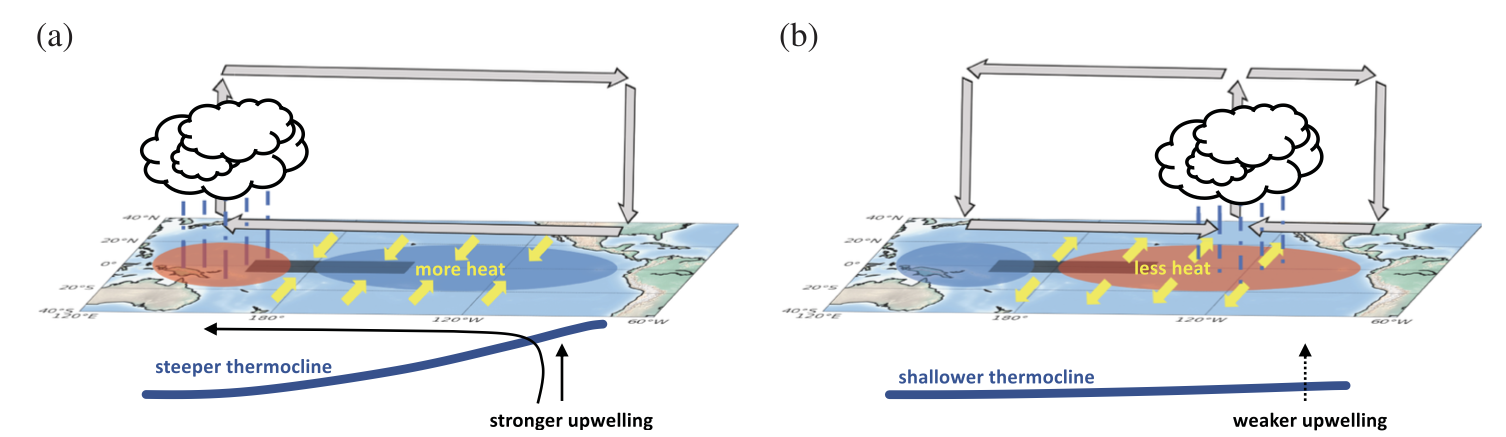
  <figcaption style="margin-top:2px;">
    <b>Figure 1.</b> <i>Atmospheric and oceanic structure during phases of El Niño Southern Oscillation (ENSO): 
    (a) La Niña and (b) El Niño. The black box indicates the region of the Niño4 index. 
    The neutral phase of ENSO is topologically similar to La Niña with less extreme anomalous 
    temperature, winds, convection, and precipitation.</i>
  </figcaption>
</figure>

The following shows the evolution of the Niño3.4 index since 1982 based on satellite SST data (source: National Oceanographic and Atmospheric Administration, https://www.ncei.noaa.gov/access/monitoring/enso/sst):

<figure style="text-align:center; margin:0;">
  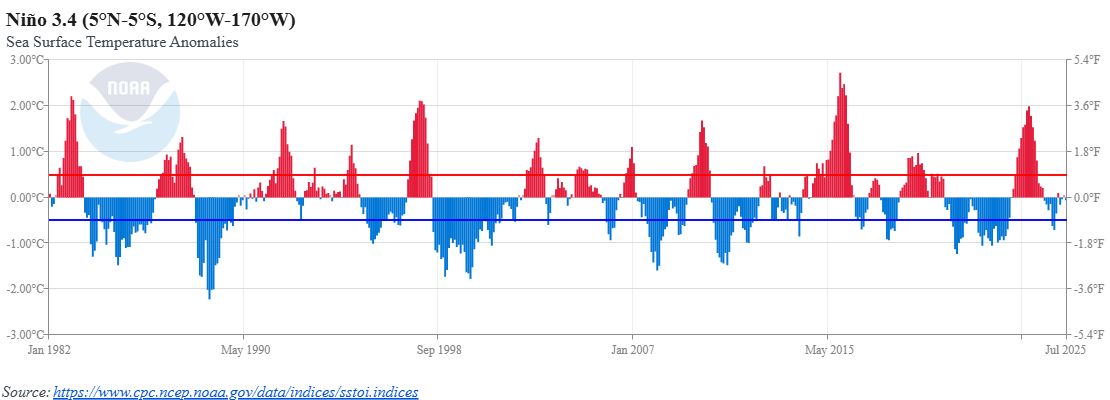
  <figcaption style="margin-top:2px;">
    <b>Figure 2.</b> <i>Niño3.4 index time series (1982–2025) showing sea surface temperature anomalies; 
    positive values indicate El Niño (red) and negative values indicate La Niña (blue). 
    Data source: NOAA CPC.</i>
  </figcaption>
</figure>


# The task
In this tutorial, we aim to predict the Niño3.4 index for a future month using values from previous months as input features. We will demonstrate machine learning workflows for up to three-month ahead predictions using different ML models.

The tutorial is divided into four main parts:

1. **Data loading and pre-processing**: Compute the monthly Niño3.4 index using air temperature data from the ERA5 reanalysis.
> **Note:** The Niño3.4 index is typically calculated using sea surface temperature (SST). However, since ERA5 does not provide actual SST, we will approximate it using surface air temperature, i.e., the 2-metre air temperature (`t2m`).

2. **Forecasting using XGBoost**: Train an XGBoost model to predict the Niño3.4 index up to three months into the future.

3. **Forecasting Using a Multilayer Perceptron (MLP)**: Train a multi-layer perceptron (MLP) to predict the Niño3.4 index up to three months into the future.

4. **Model evaluation and comparison:** Assess and compare the performance of the forecasting models.



# Part 1: Data loading and pre-processing

### 1. Load ERA5 2-metre air temperature (t2m) monthly-averaged with PyEarthTools


In [1]:
# Necessary import
import pyearthtools.data
import pyearthtools.pipeline as petpipe
import site_archive_nci
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import scipy.stats

import torch
import torch.nn as nn
import torch.optim as optim
import random

/opt/conda/envs/pet/lib/python3.11/site-packages/pyearthtools/data/indexes/_indexes.py:790: IndexWarning: Data requested at a higher resolution than available. hour > month
  warnings.warn(


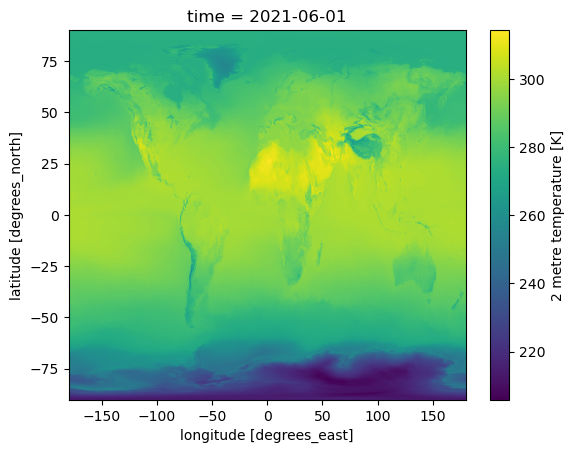

In [2]:
# Use pyearthtools data archive to access the data of interest
variables_of_interest = ['2t']
product = 'monthly-averaged'
accessor = pyearthtools.data.archive.ERA5(variables_of_interest, product=product) # Note - if you change 'product' to 'reanalysis' you can get the 6-hour timesteps

# Visualise the data on one sample
doi = '2021-06-09T06' 
accessor[doi]['2t'].plot()


### 2. Retreive monthly data from 1970 to end of 2024

<xarray.Dataset> Size: 5GB
Dimensions:    (time: 660, latitude: 721, longitude: 1440)
Coordinates:
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 5kB 1970-01-01 1970-02-01 ... 2024-12-01
Data variables:
    2t         (time, latitude, longitude) float64 5GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...


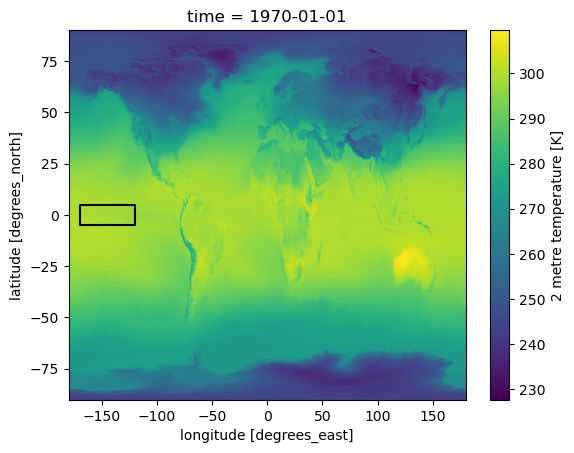

In [3]:
# Consider monthly timeseries from 1970 to 2024
start = '1970-01-01'
end = '2024-12-31'

t2_global_ts = accessor.series(start, end) 

# plot the first month in the timeseries
print(t2_global_ts)
t2_global_ts['2t'][0].plot()

# Plot the Nino 3.4 index region on top:
plt.plot([-170,-120,-120,-170,-170],[-5,-5,5,5,-5],'-k')

### 3. Crop the global data to the Niño3.4 region (5°N-5°S, 170°W-120°W) and calculate spatial means

The resulting plot shows the priminent "cold tongue" feature of colder SSTs along the equator in the eastern Pacific.

<xarray.Dataset> Size: 44MB
Dimensions:    (time: 660, latitude: 41, longitude: 201)
Coordinates:
  * longitude  (longitude) float32 804B -170.0 -169.8 -169.5 ... -120.2 -120.0
  * latitude   (latitude) float32 164B 5.0 4.75 4.5 4.25 ... -4.5 -4.75 -5.0
  * time       (time) datetime64[ns] 5kB 1970-01-01 1970-02-01 ... 2024-12-01
Data variables:
    2t         (time, latitude, longitude) float64 44MB dask.array<chunksize=(1, 41, 201), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...


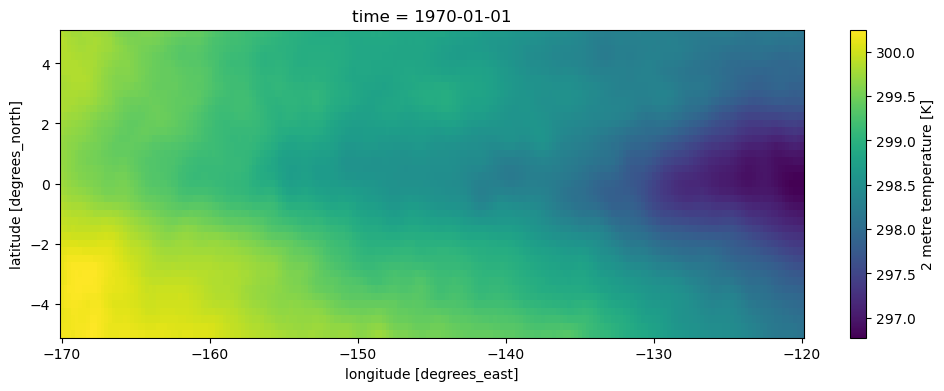

In [4]:
# Subset the dataset within the specified latitude and longitude bounds 
t2_region_ts = t2_global_ts.sel(
    latitude=slice(5, -5),         # From 5°N to 5°S 
    longitude=slice(-170, -120)    # From 170°W to 120°W
)
print(t2_region_ts)
t2_region_ts['2t'][0].plot(figsize=(12,4))


In [5]:
# Calculate spatial means (note that this mean is not area-weighted - which is not strictly correct but makes little difference in this case)
t2_ts = t2_region_ts['2t'].mean(dim=['latitude', 'longitude'])

# Convert to pandas DataFrame with 3 columns 'year' 'month' and 't2m' (i.e. 2t timeseries)
df = t2_ts.to_dataframe(name='t2m').reset_index()

# Extract year and month from 'time'
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month

# Keep required columns
t2_df = df[['year', 'month', 't2m']]

print("\nPrinting first 10 rows of t2_df:")
t2_df.head(10)



Printing first 10 rows of t2_df:


,year,month,t2m
0,1970,1,298.799964
1,1970,2,298.884142
2,1970,3,298.863824
3,1970,4,299.425736
4,1970,5,299.650770
5,1970,6,299.316589
6,1970,7,298.237027
7,1970,8,298.046338
8,1970,9,297.680157
9,1970,10,297.906577


### 4. Calculate the Niño3.4 index
The Niño3.4 index is a time series that, in this workflow, will be calculated from t2m data. The process involves computing the monthly climatology (typically computed over a standardised time period such as 1980-2020, although here we use all the data), calculating anomalies relative to this climatology, removing low-frequency trends using a 5-year moving average, applying a 5-month running mean to smooth short-term variability, and finally normalising by the standard deviation of the resulting time series.
Note that the specific steps and parameters for calculating the Niño3.4 index may vary depending on the dataset or the requirements of a particular analysis.

In [6]:
# Calculate monthly climatology
monthly_clim = t2_df.groupby('month')['t2m'].mean()

# Assign the climatology value to each row
t2_df['monthly_clim'] = t2_df['month'].map(monthly_clim)

# Calculate monthly anomalies
t2_df['anom'] = t2_df['t2m'] - t2_df['monthly_clim']
 
# Subtract 5-year moving average to remove trend
t2_df['anom_detrended'] = t2_df['anom'] - t2_df['anom'].rolling(window=60, center=True, min_periods=1).mean()

# Apply 5 month running average
t2_df['anom_smoothed'] = t2_df['anom_detrended'].rolling(window=5, center=True, min_periods=1).mean()

# Normalise by the standard deviation of the time series
std_val = t2_df['anom_smoothed'].std()
t2_df['nino3.4'] = t2_df['anom_smoothed'] / std_val

print("\nPrinting first 10 rows of t2_df:")
t2_df.head(10)


Printing first 10 rows of t2_df:


,year,month,t2m,monthly_clim,anom,anom_detrended,anom_smoothed,nino3.4
0,1970,1,298.799964,298.664784,0.135180,0.797918,0.568150,0.885935
1,1970,2,298.884142,298.846780,0.037362,0.653045,0.515593,0.803981
2,1970,3,298.863824,299.178853,-0.315029,0.253487,0.496437,0.774111
3,1970,4,299.425736,299.585783,-0.160047,0.357922,0.371018,0.578540
4,1970,5,299.650770,299.701533,-0.050762,0.419813,0.114479,0.178510
5,1970,6,299.316589,299.568230,-0.251641,0.170821,-0.045365,-0.070739
6,1970,7,298.237027,299.242830,-1.005803,-0.629650,-0.278800,-0.434741
7,1970,8,298.046338,298.925642,-0.879304,-0.545729,-0.470833,-0.734185
8,1970,9,297.680157,298.792747,-1.112591,-0.809253,-0.699846,-1.091294
9,1970,10,297.906577,298.731676,-0.825098,-0.540353,-0.793144,-1.236776


### 5. Prepare datasets with lagged indices (t-2, t-1, t, t+1, t+2, t+3, t+4, t+5 and t+6)
The lagged terms nino3.4_tminus2 and nino3.4_tminus1, along with nino3.4_t, are used as feature variables. The columns nino3.4_tplus1, nino3.4_tplus2, nino3.4_tplus3, nino3.4_tplus4, nino3.4_tplus5 and nino3.4_tplus6 serve as the target variables that the models will forecast.

In [7]:
# Select only the required columns from the original dataframe and rename nino3.4 to nino3.4_t
nino_ml_df = t2_df[['year', 'month', 'nino3.4']].copy()
nino_ml_df = nino_ml_df.rename(columns={'nino3.4': 'nino3.4_t'})

# Create columns for nino3.4 at t-1 (previous month) and t-2 (two months ago)
nino_ml_df['nino3.4_tminus1'] = nino_ml_df['nino3.4_t'].shift(1)
nino_ml_df['nino3.4_tminus2'] = nino_ml_df['nino3.4_t'].shift(2)

# Create columns for nino3.4 at t+1 (next month) and up to 6 months ahead t+6 
nino_ml_df['nino3.4_tplus1'] = nino_ml_df['nino3.4_t'].shift(-1)
nino_ml_df['nino3.4_tplus2'] = nino_ml_df['nino3.4_t'].shift(-2)
nino_ml_df['nino3.4_tplus3'] = nino_ml_df['nino3.4_t'].shift(-3)
nino_ml_df['nino3.4_tplus4'] = nino_ml_df['nino3.4_t'].shift(-4)
nino_ml_df['nino3.4_tplus5'] = nino_ml_df['nino3.4_t'].shift(-5)
nino_ml_df['nino3.4_tplus6'] = nino_ml_df['nino3.4_t'].shift(-6)

print("\nPrinting first 15 rows of nino_ml_df:")
nino_ml_df.head(15)



Printing first 15 rows of nino_ml_df:


,year,month,nino3.4_t,nino3.4_tminus1,nino3.4_tminus2,nino3.4_tplus1,nino3.4_tplus2,nino3.4_tplus3,nino3.4_tplus4,nino3.4_tplus5,nino3.4_tplus6
0,1970,1,0.885935,NaN,NaN,0.803981,0.774111,0.578540,0.178510,-0.070739,-0.434741
1,1970,2,0.803981,0.885935,NaN,0.774111,0.578540,0.178510,-0.070739,-0.434741,-0.734185
2,1970,3,0.774111,0.803981,0.885935,0.578540,0.178510,-0.070739,-0.434741,-0.734185,-1.091294
3,1970,4,0.578540,0.774111,0.803981,0.178510,-0.070739,-0.434741,-0.734185,-1.091294,-1.236776
4,1970,5,0.178510,0.578540,0.774111,-0.070739,-0.434741,-0.734185,-1.091294,-1.236776,-1.385032
5,1970,6,-0.070739,0.178510,0.578540,-0.434741,-0.734185,-1.091294,-1.236776,-1.385032,-1.501755
6,1970,7,-0.434741,-0.070739,0.178510,-0.734185,-1.091294,-1.236776,-1.385032,-1.501755,-1.707752
7,1970,8,-0.734185,-0.434741,-0.070739,-1.091294,-1.236776,-1.385032,-1.501755,-1.707752,-1.603390
8,1970,9,-1.091294,-0.734185,-0.434741,-1.236776,-1.385032,-1.501755,-1.707752,-1.603390,-1.446570
9,1970,10,-1.236776,-1.091294,-0.734185,-1.385032,-1.501755,-1.707752,-1.603390,-1.446570,-1.309427


### It is also common to include the month as an additional feature. To capture its periodic nature, the month can be encoded as cyclic features using sine and cosine transformations.

In [8]:
# In case we need to include 'month' as a predictor, then encode it as cyclic features
nino_ml_df['month_sin'] = np.sin(2 * np.pi * nino_ml_df['month'] / 12)
nino_ml_df['month_cos'] = np.cos(2 * np.pi * nino_ml_df['month'] / 12)

print("\nPrinting first 10 rows of nino_ml_df:")
nino_ml_df.head(10)


Printing first 10 rows of nino_ml_df:


,year,month,nino3.4_t,nino3.4_tminus1,nino3.4_tminus2,nino3.4_tplus1,nino3.4_tplus2,nino3.4_tplus3,nino3.4_tplus4,nino3.4_tplus5,nino3.4_tplus6,month_sin,month_cos
0,1970,1,0.885935,NaN,NaN,0.803981,0.774111,0.578540,0.178510,-0.070739,-0.434741,5.000000e-01,8.660254e-01
1,1970,2,0.803981,0.885935,NaN,0.774111,0.578540,0.178510,-0.070739,-0.434741,-0.734185,8.660254e-01,5.000000e-01
2,1970,3,0.774111,0.803981,0.885935,0.578540,0.178510,-0.070739,-0.434741,-0.734185,-1.091294,1.000000e+00,6.123234e-17
3,1970,4,0.578540,0.774111,0.803981,0.178510,-0.070739,-0.434741,-0.734185,-1.091294,-1.236776,8.660254e-01,-5.000000e-01
4,1970,5,0.178510,0.578540,0.774111,-0.070739,-0.434741,-0.734185,-1.091294,-1.236776,-1.385032,5.000000e-01,-8.660254e-01
5,1970,6,-0.070739,0.178510,0.578540,-0.434741,-0.734185,-1.091294,-1.236776,-1.385032,-1.501755,1.224647e-16,-1.000000e+00
6,1970,7,-0.434741,-0.070739,0.178510,-0.734185,-1.091294,-1.236776,-1.385032,-1.501755,-1.707752,-5.000000e-01,-8.660254e-01
7,1970,8,-0.734185,-0.434741,-0.070739,-1.091294,-1.236776,-1.385032,-1.501755,-1.707752,-1.603390,-8.660254e-01,-5.000000e-01
8,1970,9,-1.091294,-0.734185,-0.434741,-1.236776,-1.385032,-1.501755,-1.707752,-1.603390,-1.446570,-1.000000e+00,-1.836970e-16
9,1970,10,-1.236776,-1.091294,-0.734185,-1.385032,-1.501755,-1.707752,-1.603390,-1.446570,-1.309427,-8.660254e-01,5.000000e-01


### Including lagged terms in the dataset introduces NaN values for the initial time steps, since there is no prior data for those periods. We remove these rows with missing values to ensure the feature and target variables are properly aligned. After this step, the dataset is ready for building and training forecasting models.

In [9]:
nino_ml_ready_df = nino_ml_df.dropna().reset_index(drop=True)
print("\nPrinting first 10 rows of nino_ml_ready_df:")
nino_ml_ready_df.head(10)


Printing first 10 rows of nino_ml_ready_df:


,year,month,nino3.4_t,nino3.4_tminus1,nino3.4_tminus2,nino3.4_tplus1,nino3.4_tplus2,nino3.4_tplus3,nino3.4_tplus4,nino3.4_tplus5,nino3.4_tplus6,month_sin,month_cos
0,1970,3,0.774111,0.803981,0.885935,0.578540,0.178510,-0.070739,-0.434741,-0.734185,-1.091294,1.000000e+00,6.123234e-17
1,1970,4,0.578540,0.774111,0.803981,0.178510,-0.070739,-0.434741,-0.734185,-1.091294,-1.236776,8.660254e-01,-5.000000e-01
2,1970,5,0.178510,0.578540,0.774111,-0.070739,-0.434741,-0.734185,-1.091294,-1.236776,-1.385032,5.000000e-01,-8.660254e-01
3,1970,6,-0.070739,0.178510,0.578540,-0.434741,-0.734185,-1.091294,-1.236776,-1.385032,-1.501755,1.224647e-16,-1.000000e+00
4,1970,7,-0.434741,-0.070739,0.178510,-0.734185,-1.091294,-1.236776,-1.385032,-1.501755,-1.707752,-5.000000e-01,-8.660254e-01
5,1970,8,-0.734185,-0.434741,-0.070739,-1.091294,-1.236776,-1.385032,-1.501755,-1.707752,-1.603390,-8.660254e-01,-5.000000e-01
6,1970,9,-1.091294,-0.734185,-0.434741,-1.236776,-1.385032,-1.501755,-1.707752,-1.603390,-1.446570,-1.000000e+00,-1.836970e-16
7,1970,10,-1.236776,-1.091294,-0.734185,-1.385032,-1.501755,-1.707752,-1.603390,-1.446570,-1.309427,-8.660254e-01,5.000000e-01
8,1970,11,-1.385032,-1.236776,-1.091294,-1.501755,-1.707752,-1.603390,-1.446570,-1.309427,-1.003230,-5.000000e-01,8.660254e-01
9,1970,12,-1.501755,-1.385032,-1.236776,-1.707752,-1.603390,-1.446570,-1.309427,-1.003230,-0.659450,-2.449294e-16,1.000000e+00


---

# Part 2:Forecasting using XGBoost

### What is XGBoost?

**XGBoost (Extreme Gradient Boosting)** is a supervised machine learning algorithm used for regression and classification problems. It is based on a method called **gradient boosting**, which builds an ensemble (a group) of decision trees to make predictions.

#### How does it work?

1. **Decision trees** are simple models that split the data based on feature values (e.g., "Is SST > 1.5?") to predict an outcome. However, a single tree is usually not very accurate.

2. **Gradient boosting** improves accuracy by building a sequence of trees. 
   - The first tree makes an initial prediction.
   - The next tree tries to correct the errors of the previous one.
   - This process repeats, with each new tree focusing on the **residuals** (the difference between the true value and the predicted value) of the previous model.
   - The final prediction is a weighted sum of all the trees.

In this notebook, we use XGBoost to forecast the Niño 3.4 index up to 3 months ahead using past index values and the calendar month as predictors.



## Training Framework

Our training approach is as follows:

- We split the data into training and test sets, and normalise the features to put all features are on the same scale. Note that we do not scale the target variable, as this is not required for XGBoost and is only sometimes needed for fully connected neural networks, typically when large-magnitude targets cause unstable training.
- The training data consists of years 1970–2010, while the test data covers years 2011–2024.
- In many machine learning workflows, it is common to create a separate validation set from the training data to monitor performance and tune hyperparameters. However, in this case, we do **not** use any validation set and train the model directly on the full training set. 
- Here, we rely on the standard configuration of XGBoost, which typically gives good results without tuning.


In [28]:
# Set lag months into the future (e.g., 1, 2,.. or 6)
lag_months_ahead = 2  # change to 1, 2, 3, 4, 5 or 6 as needed

# Dynamically set target column name
target_column = f'nino3.4_tplus{lag_months_ahead}' #'nino3.4_tplus1', '..., or 'nino3.4_tplus6'

print(f"Forecasting {lag_months_ahead} month(s) into the future. Target column: {target_column}")

# Define predictors and target column names for XGBoost
predictor_columns = ['nino3.4_tminus2', 'nino3.4_tminus1',  'nino3.4_t'] # remove/add 'month_sin', 'month_cos' as needed



Forecasting 2 month(s) into the future. Target column: nino3.4_tplus2


In [29]:
# Subset dataframe for predictors and target
xgboost_ready_df = nino_ml_ready_df[['year', 'month'] + predictor_columns + [target_column]].copy()

# Define training and testing years
train_years = range(1970, 2011)  # 1980-2010 for training
test_years = range(2011, 2025)   # 2011-2024 for testing

# Create training and testing dataframes
train_df = xgboost_ready_df[xgboost_ready_df['year'].isin(train_years)].reset_index(drop=True)
test_df  = xgboost_ready_df[xgboost_ready_df['year'].isin(test_years)].reset_index(drop=True)

print("First 10 rows of train_df:")
print(train_df.head(10))

print("\nFirst 10 rows of test_df:")
print(test_df.head(10))

# Create benchmark dataframe that contains current month nino3, i.e., nino3.4_t
benchmark_df = test_df[['year', 'month', 'nino3.4_t']].copy()

First 10 rows of train_df:
   year  month  nino3.4_tminus2  nino3.4_tminus1  nino3.4_t  nino3.4_tplus2
0  1970      3         0.885935         0.803981   0.774111        0.178510
1  1970      4         0.803981         0.774111   0.578540       -0.070739
2  1970      5         0.774111         0.578540   0.178510       -0.434741
3  1970      6         0.578540         0.178510  -0.070739       -0.734185
4  1970      7         0.178510        -0.070739  -0.434741       -1.091294
5  1970      8        -0.070739        -0.434741  -0.734185       -1.236776
6  1970      9        -0.434741        -0.734185  -1.091294       -1.385032
7  1970     10        -0.734185        -1.091294  -1.236776       -1.501755
8  1970     11        -1.091294        -1.236776  -1.385032       -1.707752
9  1970     12        -1.236776        -1.385032  -1.501755       -1.603390

First 10 rows of test_df:
   year  month  nino3.4_tminus2  nino3.4_tminus1  nino3.4_t  nino3.4_tplus2
0  2011      1        -1.807909   

### Here, we examine the distribution of the target variable (`nino3.4_tplus1`, `nino3.4_tplus2`, or `nino3.4_tplus3`) in both the training and test datasets. It is important to ensure that the training data is representative, so that the model can generalise well to new, unseen data.
Question - given the plot below, is the training data sufficiently representative of the test data? Can you think of any way we could use a statistical test to determine whether they are representative?

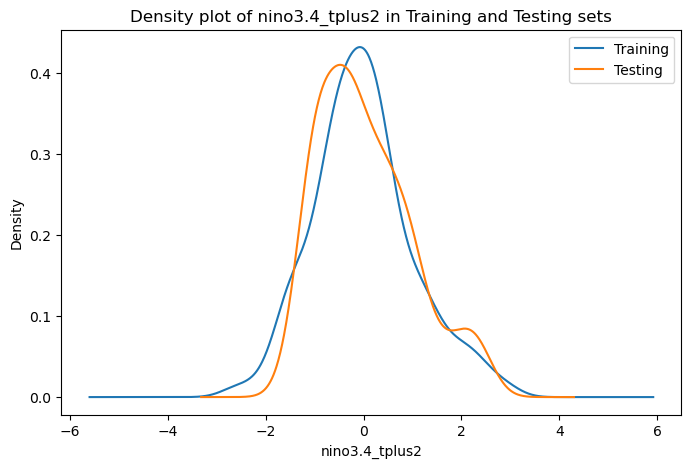

In [30]:
# Density plots
plt.figure(figsize=(8, 5))
train_df[target_column].plot.kde(label='Training')
test_df[target_column].plot.kde(label='Testing')
plt.xlabel(target_column)
plt.ylabel('Density')
plt.title(f'Density plot of {target_column} in Training and Testing sets')
plt.legend()
plt.show()


In [31]:
# Select features and target
X_train = train_df[predictor_columns]
y_train = train_df[target_column]
X_test = test_df[predictor_columns]
y_test = test_df[target_column]


print("First 10 rows of X_train:\n")
display(X_train.head(10))

print("\nFirst 10 rows of y_train:\n")
display(y_train.head(10))


print("First 10 rows of X_test:\n")
display(X_test.head(10))

print("\nFirst 10 rows of y_test:\n")
display(y_test.head(10))

First 10 rows of X_train:



,nino3.4_tminus2,nino3.4_tminus1,nino3.4_t
0,0.885935,0.803981,0.774111
1,0.803981,0.774111,0.578540
2,0.774111,0.578540,0.178510
3,0.578540,0.178510,-0.070739
4,0.178510,-0.070739,-0.434741
5,-0.070739,-0.434741,-0.734185
6,-0.434741,-0.734185,-1.091294
7,-0.734185,-1.091294,-1.236776
8,-1.091294,-1.236776,-1.385032
9,-1.236776,-1.385032,-1.501755



First 10 rows of y_train:



0    0.178510
1   -0.070739
2   -0.434741
3   -0.734185
4   -1.091294
5   -1.236776
6   -1.385032
7   -1.501755
8   -1.707752
9   -1.603390
Name: nino3.4_tplus2, dtype: float64

First 10 rows of X_test:



,nino3.4_tminus2,nino3.4_tminus1,nino3.4_t
0,-1.807909,-1.731953,-1.579121
1,-1.731953,-1.579121,-1.309494
2,-1.579121,-1.309494,-0.990207
3,-1.309494,-0.990207,-0.618779
4,-0.990207,-0.618779,-0.389014
5,-0.618779,-0.389014,-0.309586
6,-0.389014,-0.309586,-0.327594
7,-0.309586,-0.327594,-0.479485
8,-0.327594,-0.479485,-0.726601
9,-0.479485,-0.726601,-0.900945



First 10 rows of y_test:



0   -0.990207
1   -0.618779
2   -0.389014
3   -0.309586
4   -0.327594
5   -0.479485
6   -0.726601
7   -0.900945
8   -1.018265
9   -1.092281
Name: nino3.4_tplus2, dtype: float64

In [32]:
# Standardise our input features (zero mean, unit variance).
# Not required for XGBoost, which splits on feature thresholds and is scale-invariant.
# Done here to reuse the same preprocessed data later with a Multilayer Perceptron, which is sensitive to feature scaling.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train an XGBoost model

In [33]:
# Train a simple XGBoost model
model = XGBRegressor(random_state=42) # Use any integer seed 
model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = model.predict(X_test_scaled)

# Quick evaluation of model performance using correlation and RMSE 
correlation = np.corrcoef(y_test, y_pred)[0, 1]
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Correlation between predicted and actual values: {correlation:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

Correlation between predicted and actual values: 0.963
Root Mean Squared Error (RMSE): 0.264


### Correctly align the predicted values (forecasts for the next month(s)) with their corresponding time periods.

In [34]:
# helper function
# Compute forecast year and month `n` months ahead for all rows in a DataFrame.
def add_n_months(df, n):
    """
    Return a DataFrame with original year/month and forecast year/month `n` months after.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with 'year' and 'month' integer columns.
    n : int
        Number of months to add.

    Returns
    -------
    pandas.DataFrame
        DataFrame with 'year', 'month', 'forecast_year', 'forecast_month'.
    """
    total_months = df['year'] * 12 + df['month'] - 1 + n
    forecast_year = total_months // 12
    forecast_month = (total_months % 12) + 1

    return pd.DataFrame({
        'year': df['year'].values,
        'month': df['month'].values,
        'forecast_year': forecast_year,
        'forecast_month': forecast_month
    })


In [35]:
# use add_n_months function to create a forecast dataframe for y_pred and y_test. Also add nino3.4 of the current month value. Later, we'll use it as the forecast for the next month(s) and benchmark the model against it

forecast_dates = add_n_months(test_df, lag_months_ahead)


# Construct the forecast DataFrame with predicted and true values aligned to t+n
forecasts_df = pd.DataFrame({
    'forecast_year': forecast_dates['forecast_year'],
    'forecast_month': forecast_dates['forecast_month'],
    'year': forecast_dates['year'],
    'month': forecast_dates['month'],
    'y_pred_xgboost': y_pred,
    'y_test': y_test.reset_index(drop=True)
})


# Merge forecasts_df with the climatology DataFrame on forecast_month
forecasts_df = forecasts_df.merge(benchmark_df, on=['year','month'], how='left').drop(columns=['year','month'])

# Drop the redundant 'month' column from the merge
#forecasts_df = forecasts_df.drop(columns=['month'])

forecasts_df.head(10)

,forecast_year,forecast_month,y_pred_xgboost,y_test,nino3.4_t
0,2011,3,-0.914427,-0.990207,-1.579121
1,2011,4,-0.709423,-0.618779,-1.309494
2,2011,5,-0.699197,-0.389014,-0.990207
3,2011,6,-0.550975,-0.309586,-0.618779
4,2011,7,0.015465,-0.327594,-0.389014
5,2011,8,-0.269541,-0.479485,-0.309586
6,2011,9,-0.354854,-0.726601,-0.327594
7,2011,10,-0.446217,-0.900945,-0.479485
8,2011,11,-1.008514,-1.018265,-0.726601
9,2011,12,-1.493428,-1.092281,-0.900945


---

# Part 3: Forecasting Using a Multilayer Perceptron (MLP)

### What is an MLP, and Why Use PyTorch?

A **Multilayer Perceptron (MLP)** is a basic type of neural network composed of layers of interconnected neurons. Each layer applies a linear transformation followed by a non-linear activation function, allowing the network to model complex relationships in the data.

An MLP typically has:
- An **input layer** (taking your features),
- One or more **hidden layers** (which process the data),
- An **output layer** (producing the prediction).

In this notebook, we use **PyTorch**, an open-source deep learning framework, to build and train our MLP model. PyTorch gives us flexibility and control over how models are defined, trained, and evaluated.


In [36]:
# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # Only needed if using GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#### Splitting into training and validation sets
To monitor whether our model is overfitting, we split the training data into:
- A **training set**, used for updating model weights.
- A **validation set**, used to evaluate model performance during training (but not used to update weights). Typically it is also used for **Hyperparameter tuning** (e.g., number of layers, neurons, learning rate), **Model selection** (e.g., choosing between architectures), and **Early stopping** (stopping training if performance stops improving).

It is standard practice in machine learning to use the **validation set** to check how well the model generalises to unseen data **before** we even touch the test set.

We previously standardised our input features (zero mean, unit variance) using `StandardScaler`. This is important because neural networks are sensitive to the scale of input data. Standardised inputs improve training stability and convergence.

Before training our Multilayer Perceptron (MLP) using PyTorch, we need to convert our NumPy arrays (or pandas DataFrames) into **PyTorch tensors**, which are the core data structures used by PyTorch for model training and inference. Tensors allow PyTorch to automatically compute gradients during training using its `autograd` system, which is essential for backpropagation and updating model parameters.


In [37]:
# Split original training data into training and validation
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_scaled, y_train.values, test_size=0.2, random_state=SEED
)

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train_sub, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_sub, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

### Defining the MLP Model Structure

Here we define our MLP model by subclassing `nn.Module`, the base class for all PyTorch models.

We use `nn.Sequential()` to stack layers in order:

- `nn.Linear(input_dim, 64)`: a fully connected layer mapping inputs to 64 hidden units.
- `nn.ReLU()`: a non-linear activation function that introduces non-linearity into the model.
- `nn.Linear(64, 32)`: a second hidden layer with 32 units.
- Another `nn.ReLU()` activation.
- `nn.Linear(32, 1)`: the output layer, which maps to a single predicted value (since this is a regression task).

The `forward()` method defines how the input flows through the layers when making predictions.

This is a small and simple MLP, we use it here to demonstrate how neural networks can be applied to a time series forecasting task, where the goal is to predict the Niño 3.4 index several months ahead.

Below, we proceed to:
- Defining the MLP model.
- Training the model while recording both training and validation loss.
- Ploting the losses to assess training dynamics.

In [38]:
# Define MLP model
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

# Initialize model
input_dim = X_train_tensor.shape[1]
model = MLP(input_dim)

# Loss and optimiser
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Training the MLP and Monitoring Validation Loss

In this section, we train the MLP model using the training set and evaluate its performance on the validation set at each epoch.

#### What's happening during training?
- For each epoch (a full pass through the training data), the model:
  - Computes predictions on the training set.
  - Calculates the **Mean Squared Error (MSE)** loss between predictions and actual values.
  - Computes gradients using backpropagation and updates the model parameters using the **Adam** optimiser.


In [39]:
# Training loop with loss tracking
n_epochs = 150
train_losses = []
val_losses = []

model.train()
for epoch in range(n_epochs):
    # Train
    optimizer.zero_grad()
    output = model(X_train_tensor)
    loss = criterion(output, y_train_tensor)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Validate
    model.eval()
    with torch.no_grad():
        val_output = model(X_val_tensor)
        val_loss = criterion(val_output, y_val_tensor)
        val_losses.append(val_loss.item())
    model.train()  # back to training mode


#### Visualising loss
We plot both the training and validation loss curves. Ideally, the validation loss should decrease alongside the training loss and then stabilise. If it starts increasing, it suggests overfitting.


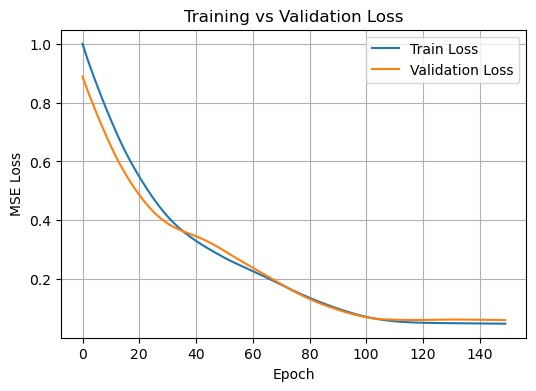

In [40]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


In [41]:
# Predict
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    y_pred = y_pred_tensor.numpy().flatten()


# Quick evaluation of model performance using correlation and RMSE 
correlation = np.corrcoef(y_test, y_pred)[0, 1]
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Correlation between predicted and actual values: {correlation:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

Correlation between predicted and actual values: 0.973
Root Mean Squared Error (RMSE): 0.221


In [42]:
# Assign MLP predictions to a new column in forecasts_df

forecasts_df['y_pred_mlp'] = y_pred  

---

# Part 4: Model evaluation and comparison

### Model Evaluation and Comparison

In this section, we evaluate the performance of the forecasting models using the test dataset.  
As a benchmark, we include the **current-month niño3.4 value**, as a simple reference point to assess whether the machine learning models add value beyond 'persistence', i.e., forecasting the current index.

The following metrics are used to assess model performance:

- **Pearson correlation coefficient**, to measure the linear relationship between predicted and actual values.
- **Root Mean Square Error (RMSE)**, to quantify average forecast error magnitude.
- **Explained Variability (R²)**, to indicate how much of the variance in the true values is captured by the model.

We will also:

- Plot the time series of the true values alongside the model forecasts and reference (current-month niño3.4 value) for visual comparison.
- Create scatter plots of forecast vs actual values for each model, with performance metrics annotated.


### 1. Evaluating the current month niño3.4 value as a forecast

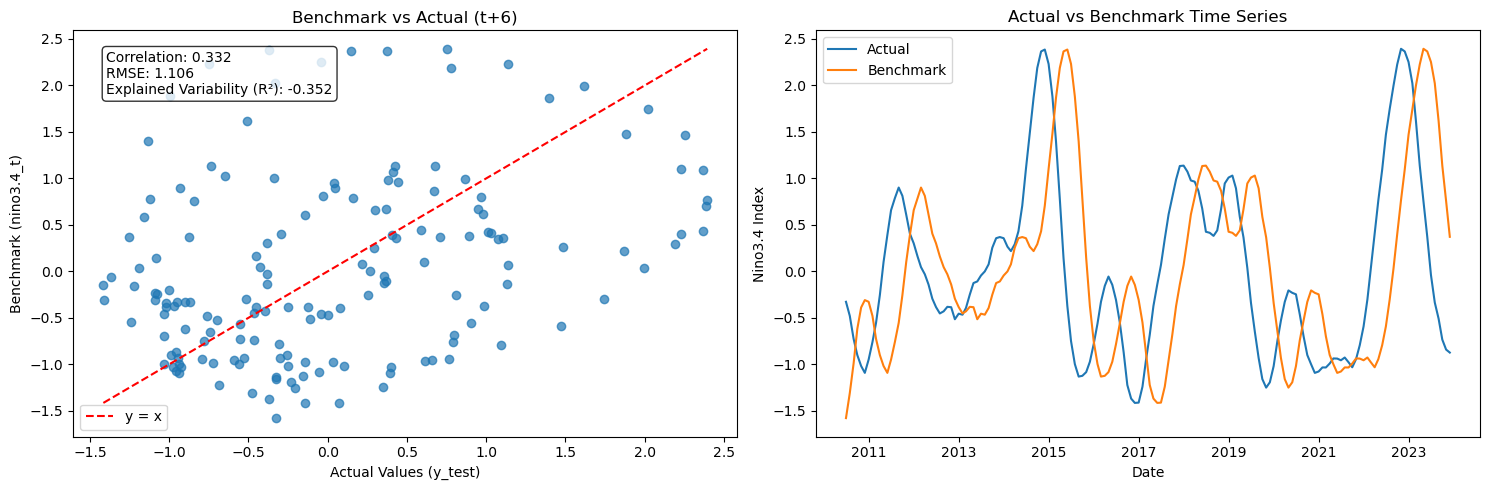

In [25]:
# If we use monthly climatology as our forecast, this is the performance that we get
# Extract true values and climatology predictions
y_true = forecasts_df['y_test']
y_bench = forecasts_df['nino3.4_t']

# Calculate metrics
correlation_bench = np.corrcoef(y_true, y_bench)[0, 1]
rmse_bench = np.sqrt(mean_squared_error(y_true, y_bench))
r2_bench = r2_score(y_true, y_bench)

# Create datetime index from forecast year/month
forecast_dates = pd.to_datetime(dict(
    year=forecasts_df['forecast_year'],
    month=forecasts_df['forecast_month'],
    day=1
))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot: Climatology vs Actual
axes[0].scatter(y_true, y_bench, alpha=0.7)
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='y = x')
axes[0].set_xlabel('Actual Values (y_test)')
axes[0].set_ylabel('Benchmark (nino3.4_t)')
axes[0].set_title(f'Benchmark vs Actual (t+{lag_months_ahead})')
axes[0].legend()

# Annotate correlation, RMSE, and R²
stats_text = f'Correlation: {correlation_bench:.3f}\nRMSE: {rmse_bench:.3f}\nExplained Variability (R²): {r2_bench:.3f}'
axes[0].text(0.05, 0.95, stats_text, transform=axes[0].transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Time series plot
axes[1].plot(forecast_dates, y_true, label='Actual')
axes[1].plot(forecast_dates, y_bench, label='Benchmark')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Nino3.4 Index')
axes[1].set_title('Actual vs Benchmark Time Series')
axes[1].legend()

plt.tight_layout()
plt.show()

### 2. Comparing XGBoost and MLP forecasts at the selected lead time

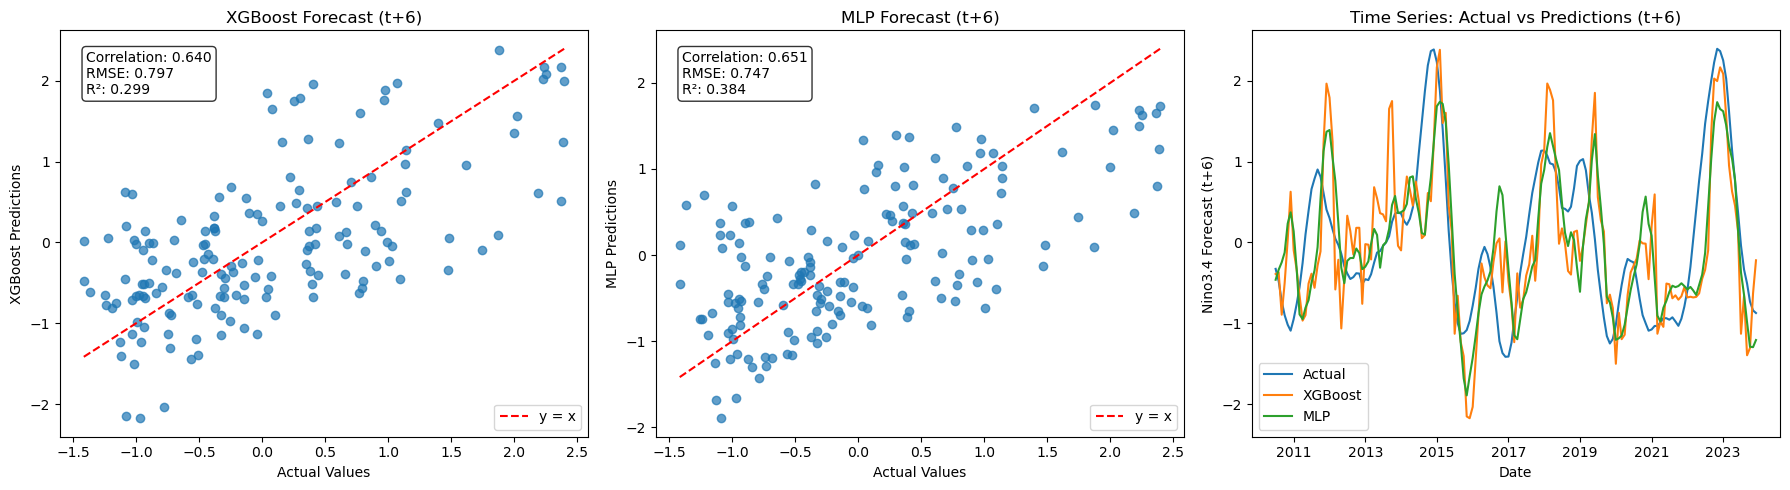

In [26]:

# Calculate metrics for XGBoost
correlation_xgboost = np.corrcoef(forecasts_df['y_test'], forecasts_df['y_pred_xgboost'])[0, 1]
rmse_xgboost = np.sqrt(mean_squared_error(forecasts_df['y_test'], forecasts_df['y_pred_xgboost']))
r2_xgboost = r2_score(forecasts_df['y_test'], forecasts_df['y_pred_xgboost'])

# Calculate metrics for MLP
correlation_mlp = np.corrcoef(forecasts_df['y_test'], forecasts_df['y_pred_mlp'])[0, 1]
rmse_mlp = np.sqrt(mean_squared_error(forecasts_df['y_test'], forecasts_df['y_pred_mlp']))
r2_mlp = r2_score(forecasts_df['y_test'], forecasts_df['y_pred_mlp'])

# Create datetime index from forecast_year and forecast_month
forecast_dates = pd.to_datetime(dict(
    year=forecasts_df['forecast_year'],
    month=forecasts_df['forecast_month'],
    day=1
))

# Plot scatter plots for both models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot: XGBoost vs Actual
axes[0].scatter(forecasts_df['y_test'], forecasts_df['y_pred_xgboost'], alpha=0.7)
axes[0].plot([forecasts_df['y_test'].min(), forecasts_df['y_test'].max()],
             [forecasts_df['y_test'].min(), forecasts_df['y_test'].max()],
             'r--', label='y = x')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('XGBoost Predictions')
axes[0].set_title(f'XGBoost Forecast (t+{lag_months_ahead})')
axes[0].legend()
axes[0].text(0.05, 0.95,
             f'Correlation: {correlation_xgboost:.3f}\nRMSE: {rmse_xgboost:.3f}\nR²: {r2_xgboost:.3f}',
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Scatter plot: MLP vs Actual
axes[1].scatter(forecasts_df['y_test'], forecasts_df['y_pred_mlp'], alpha=0.7)
axes[1].plot([forecasts_df['y_test'].min(), forecasts_df['y_test'].max()],
             [forecasts_df['y_test'].min(), forecasts_df['y_test'].max()],
             'r--', label='y = x')
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('MLP Predictions')
axes[1].set_title(f'MLP Forecast (t+{lag_months_ahead})')
axes[1].legend()
axes[1].text(0.05, 0.95,
             f'Correlation: {correlation_mlp:.3f}\nRMSE: {rmse_mlp:.3f}\nR²: {r2_mlp:.3f}',
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Time series plot: Actual vs both models
axes[2].plot(forecast_dates, forecasts_df['y_test'], label='Actual')
axes[2].plot(forecast_dates, forecasts_df['y_pred_xgboost'], label='XGBoost')
axes[2].plot(forecast_dates, forecasts_df['y_pred_mlp'], label='MLP')
axes[2].set_xlabel('Date')
axes[2].set_ylabel(f'Nino3.4 Forecast (t+{lag_months_ahead})')
axes[2].set_title(f'Time Series: Actual vs Predictions (t+{lag_months_ahead})')
axes[2].legend()

plt.tight_layout()
plt.show()


## Let’s show all plots side by side

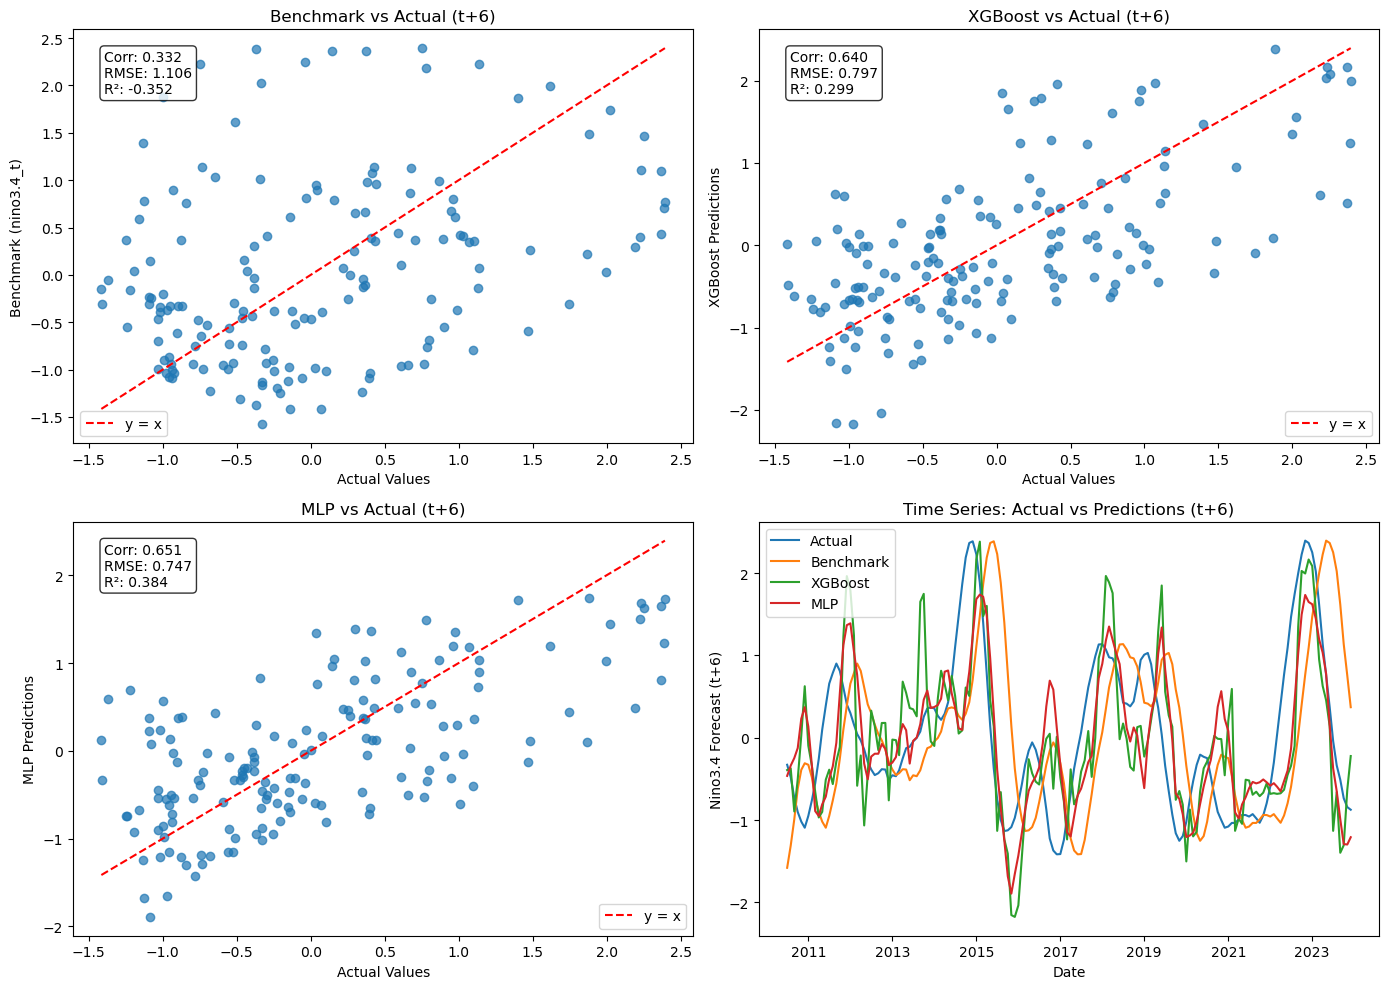

In [27]:

# Create figure: 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# --- Benchmark scatter
axes[0].scatter(y_true, y_bench, alpha=0.7)
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='y = x')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Benchmark (nino3.4_t)')
axes[0].set_title(f'Benchmark vs Actual (t+{lag_months_ahead})')
axes[0].legend()
axes[0].text(0.05, 0.95,
             f'Corr: {correlation_bench:.3f}\nRMSE: {rmse_bench:.3f}\nR²: {r2_bench:.3f}',
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- XGBoost scatter
axes[1].scatter(y_true, forecasts_df['y_pred_xgboost'], alpha=0.7)
axes[1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='y = x')
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('XGBoost Predictions')
axes[1].set_title(f'XGBoost vs Actual (t+{lag_months_ahead})')
axes[1].legend()
axes[1].text(0.05, 0.95,
             f'Corr: {correlation_xgboost:.3f}\nRMSE: {rmse_xgboost:.3f}\nR²: {r2_xgboost:.3f}',
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- MLP scatter
axes[2].scatter(y_true, forecasts_df['y_pred_mlp'], alpha=0.7)
axes[2].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='y = x')
axes[2].set_xlabel('Actual Values')
axes[2].set_ylabel('MLP Predictions')
axes[2].set_title(f'MLP vs Actual (t+{lag_months_ahead})')
axes[2].legend()
axes[2].text(0.05, 0.95,
             f'Corr: {correlation_mlp:.3f}\nRMSE: {rmse_mlp:.3f}\nR²: {r2_mlp:.3f}',
             transform=axes[2].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- Combined time series
axes[3].plot(forecast_dates, y_true, label='Actual')
axes[3].plot(forecast_dates, y_bench, label='Benchmark')
axes[3].plot(forecast_dates, forecasts_df['y_pred_xgboost'], label='XGBoost')
axes[3].plot(forecast_dates, forecasts_df['y_pred_mlp'], label='MLP')
axes[3].set_xlabel('Date')
axes[3].set_ylabel(f'Nino3.4 Forecast (t+{lag_months_ahead})')
axes[3].set_title(f'Time Series: Actual vs Predictions (t+{lag_months_ahead})')
axes[3].legend()

plt.tight_layout()
plt.show()


---

# Exercices
**You want to practice more? Try these:**
- Modify the forecast lead time (e.g., two months or three months ahead).
- Recalculate alternative ENSO indices (e.g., Niño3, Niño4) by modifying the latitude–longitude boundary region used for spatial averaging:  
  - **Niño3**: 5°N–5°S, 150°W–90°W  
  - **Niño4**: 5°N–5°S, 160°E–150°W 
- Experiment with different architectures or hyperparameters for the MLP (e.g., number of layers, neurons, learning rate).

---

# References
1. Bjerknes, J. Atmospheric teleconnections from the equatorial Pacific. *Mon. Weather Rev.* **97**, 163–172 (1969).
2. Karoly, D. J. Southern hemisphere circulation features associated with El Niño–Southern Oscillation events. *J. Clim.* **2**, 1239–1252 (1989).
3. Alexander, M. A. et al. The atmospheric bridge: The influence of ENSO teleconnections on air–sea interaction over the global oceans. *J. Clim.* **15**, 2205–2231 (2002).
4. Lyon, B. & Barnston, A. G. ENSO and the spatial extent of interannual precipitation extremes in tropical land areas. *J. Clim.* **18**, 5095–5109 (2005).  
5. Vicente‐Serrano, S. M. et al. A multiscalar global evaluation of the impact of ENSO on droughts. *J. Geophys. Res. Atmos.* **116**, (2011).  
6. Chiew, F. H. S. & McMahon, T. A. Global ENSO-streamflow teleconnection, streamflow forecasting and interannual variability. *Hydrol. Sci. J.* **47**, 505–522 (2002).
7. Kirtman, B. P. et al. Current status of ENSO forecast skill: A report to the CLIVAR Working Group on Seasonal to Interannual Prediction (2001).
8. Kitsios, V., De Mello, L. & Matear, R. Forecasting commodity returns by exploiting climate model forecasts of the El Niño–Southern Oscillation. *Environ. Data Sci.* **1**, e7 (2022).
